# Breast Cancer Diagnosis with Logistic Regression and PCA

**Course:** ADML (Advanced Machine Learning with Python)  
**Student:** Ansh Gajera  
**Enrollment No.:** 23AIML019

---

## Problem Statement
Predict whether a breast tumor is **Malignant (M)** or **Benign (B)** using 30 numeric features from digitized FNA images. This notebook compares Logistic Regression performance **with and without PCA** to evaluate the practical impact of dimensionality reduction.

## Dataset Overview
- **Source:** UCI Machine Learning Repository - Breast Cancer Wisconsin (Diagnostic)
- **Samples:** 569
- **Features:** 30 numeric predictors
- **Target:** `diagnosis` (`M` = 1, `B` = 0)
- **Task Type:** Binary classification

## Evaluation Metrics
Accuracy, Precision, Recall, F1-score, and ROC-AUC are used for model assessment.

## Notebook Roadmap
1. Imports and setup
2. Data loading and preprocessing
3. Exploratory data analysis (EDA)
4. Baseline model (without PCA)
5. PCA analysis and transformed model
6. Performance comparison and conclusions

## 1. Imports and Setup

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

# Set style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
from pathlib import Path
import zipfile

DATA_DIR = Path('.')
DATA_FILE = DATA_DIR / 'wdbc.data'
ZIP_FILE = DATA_DIR / 'breast+cancer+wisconsin+diagnostic.zip'

if DATA_FILE.exists():
    print(f'Data file found: {DATA_FILE.resolve()}')
elif ZIP_FILE.exists():
    with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
        zf.extractall(DATA_DIR)
    if not DATA_FILE.exists():
        raise FileNotFoundError('Zip extracted, but wdbc.data was not found.')
    print(f'Zip extracted successfully: {ZIP_FILE.resolve()}')
else:
    raise FileNotFoundError('Could not find wdbc.data or breast+cancer+wisconsin+diagnostic.zip in the current directory.')

Archive:  /content/breast+cancer+wisconsin+diagnostic.zip
replace wdbc.data? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: wdbc.data               
replace wdbc.names? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: wdbc.names              


## 2. Data Loading and Preparation

In [ ]:
# Define column names
col_names = ['id', 'diagnosis'] + [
    f'{measure}_{stat}'
    for stat in ['mean', 'se', 'worst']
    for measure in ['radius', 'texture', 'perimeter', 'area',
                    'smoothness', 'compactness', 'concavity',
                    'concave_points', 'symmetry', 'fractal_dimension']
]

# Load data
if 'DATA_FILE' not in globals():
    DATA_FILE = Path('wdbc.data')

df = pd.read_csv(DATA_FILE, header=None, names=col_names)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [29]:
# Drop id column (irrelevant)
df.drop(columns=['id'], inplace=True)

# Encode target: M=1, B=0
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

# Check for missing values
print('Missing values per column:')
print(df.isnull().sum().sum(), '— total missing values')

# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

# Class distribution
print(f'\nClass Distribution:')
print(df['diagnosis'].value_counts())
print(f'Malignant: {df["diagnosis"].sum()} ({df["diagnosis"].mean()*100:.1f}%)')
print(f'Benign: {(df["diagnosis"]==0).sum()} ({(1-df["diagnosis"].mean())*100:.1f}%)')

Missing values per column:
0 — total missing values
Duplicate rows: 0

Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64
Malignant: 212 (37.3%)
Benign: 357 (62.7%)


In [30]:
# Split features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Train/Test split — 80/20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 455 samples
Test set:     114 samples


## 3. Exploratory Data Analysis (EDA)

### A. Basic Overview

In [31]:
print(f'Shape: {df.shape}')
print(f'\nFeature Types:')
print(df.dtypes.value_counts())
print(f'\nSummary Statistics:')
df.describe().T.head(10)

Shape: (569, 31)

Feature Types:
float64    30
int64       1
Name: count, dtype: int64

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.00000,0.00000,0.00000,1.0000,1.0000
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
concave_points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.1957,0.3040


### B. Target Distribution

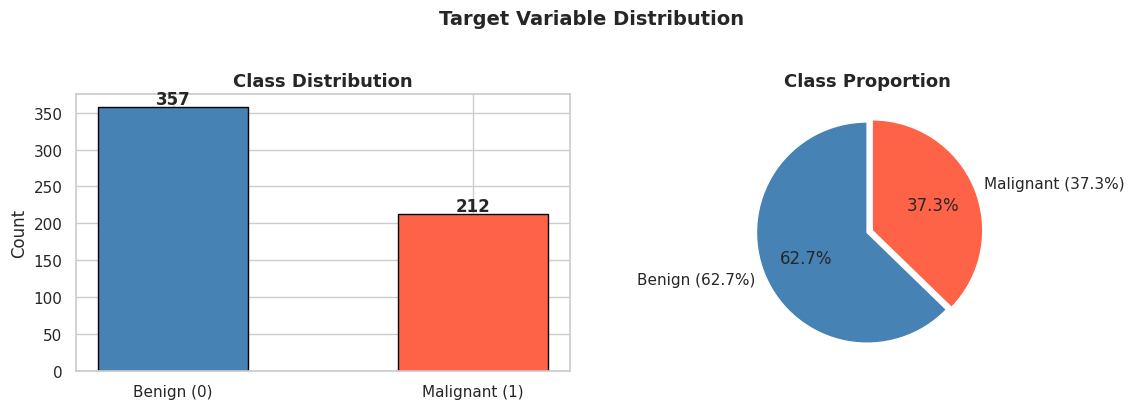

The dataset is moderately imbalanced: 62.7% Benign vs 37.3% Malignant.
This imbalance is not severe but should be monitored via Precision/Recall metrics.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
counts = df['diagnosis'].value_counts()
axes[0].bar(['Benign (0)', 'Malignant (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Benign (62.7%)', 'Malignant (37.3%)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'The dataset is moderately imbalanced: 62.7% Benign vs 37.3% Malignant.')
print('This imbalance is not severe but should be monitored via Precision/Recall metrics.')

### C. Feature Distribution Analysis

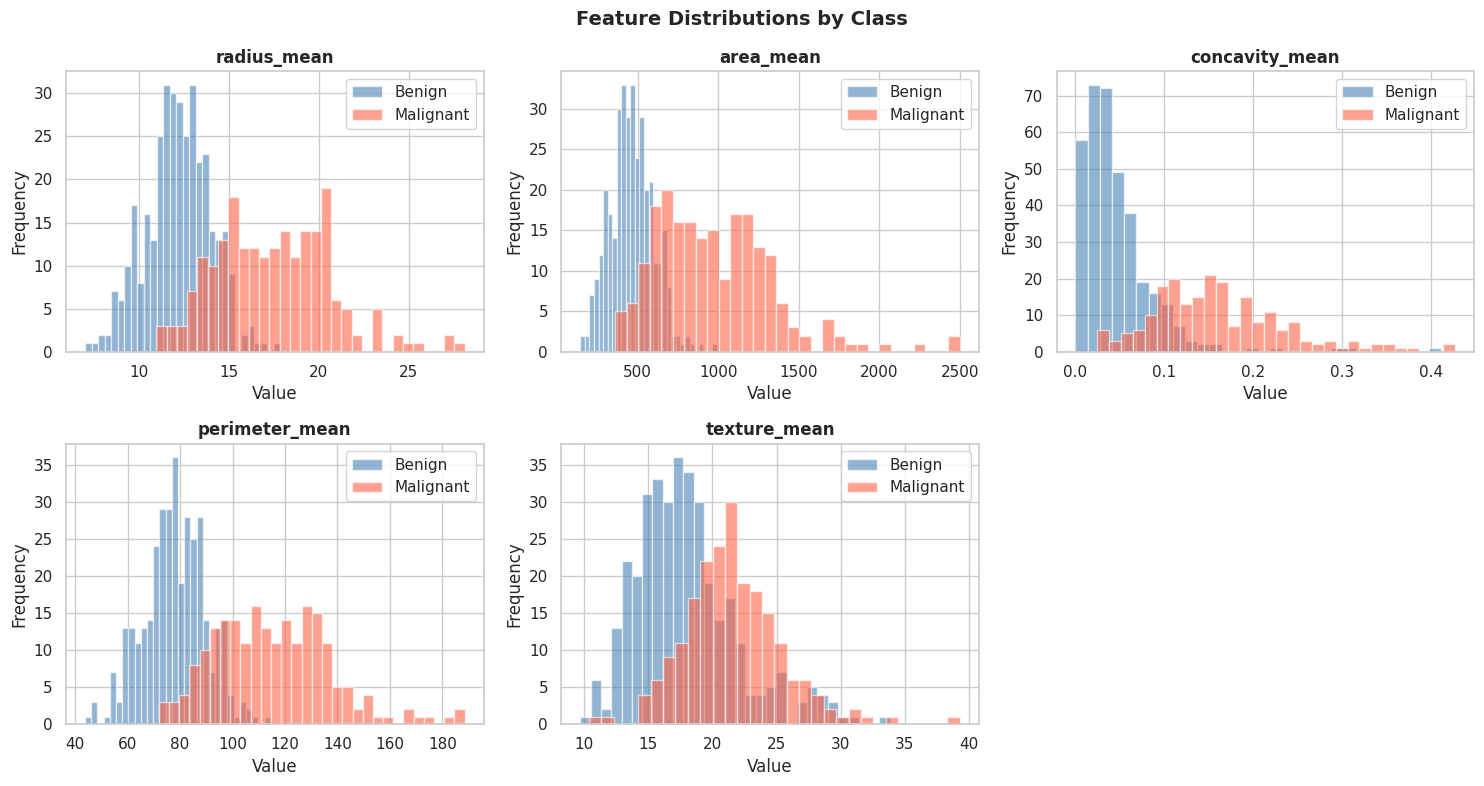

In [33]:
# Histograms for key features, split by class
key_features = ['radius_mean', 'area_mean', 'concavity_mean', 'perimeter_mean', 'texture_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    df[df['diagnosis']==0][feat].hist(ax=ax, bins=30, alpha=0.6, color='steelblue', label='Benign')
    df[df['diagnosis']==1][feat].hist(ax=ax, bins=30, alpha=0.6, color='tomato', label='Malignant')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

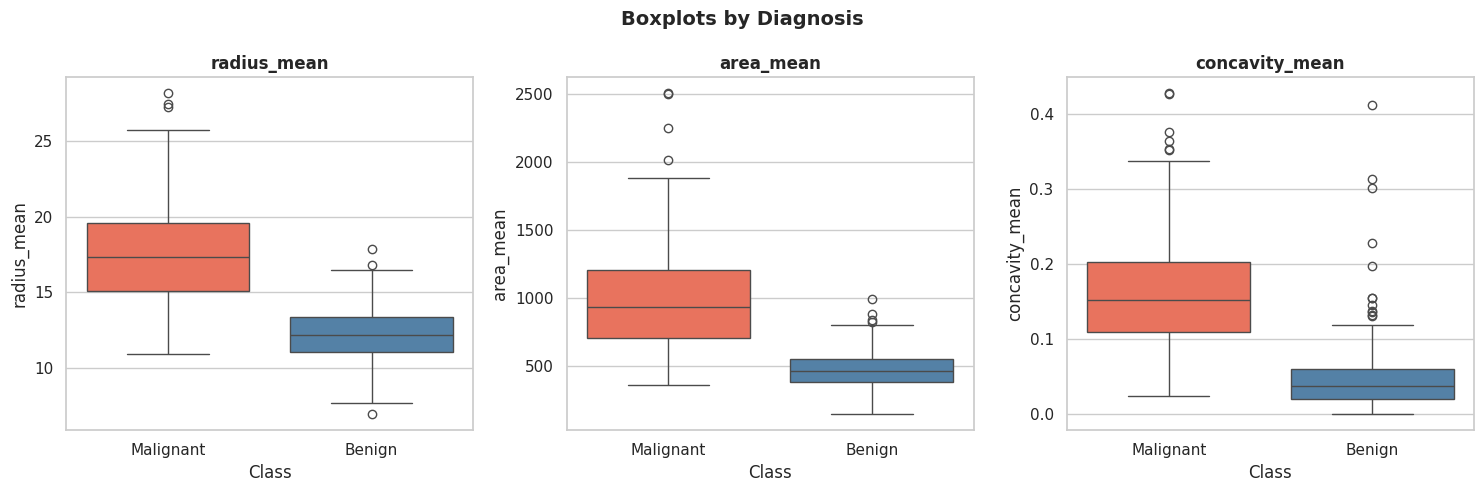

Observation: radius_mean and area_mean show clear separation between classes — strong discriminative features.


In [34]:
# Boxplots grouped by diagnosis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, ['radius_mean', 'area_mean', 'concavity_mean']):
    df_plot = df[['diagnosis', feat]].copy()
    df_plot['Class'] = df_plot['diagnosis'].map({0: 'Benign', 1: 'Malignant'})
    sns.boxplot(data=df_plot, x='Class', y=feat,
                palette={'Benign': 'steelblue', 'Malignant': 'tomato'}, ax=ax)
    ax.set_title(f'{feat}', fontweight='bold')

plt.suptitle('Boxplots by Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Observation: radius_mean and area_mean show clear separation between classes — strong discriminative features.')

### D. Correlation Analysis

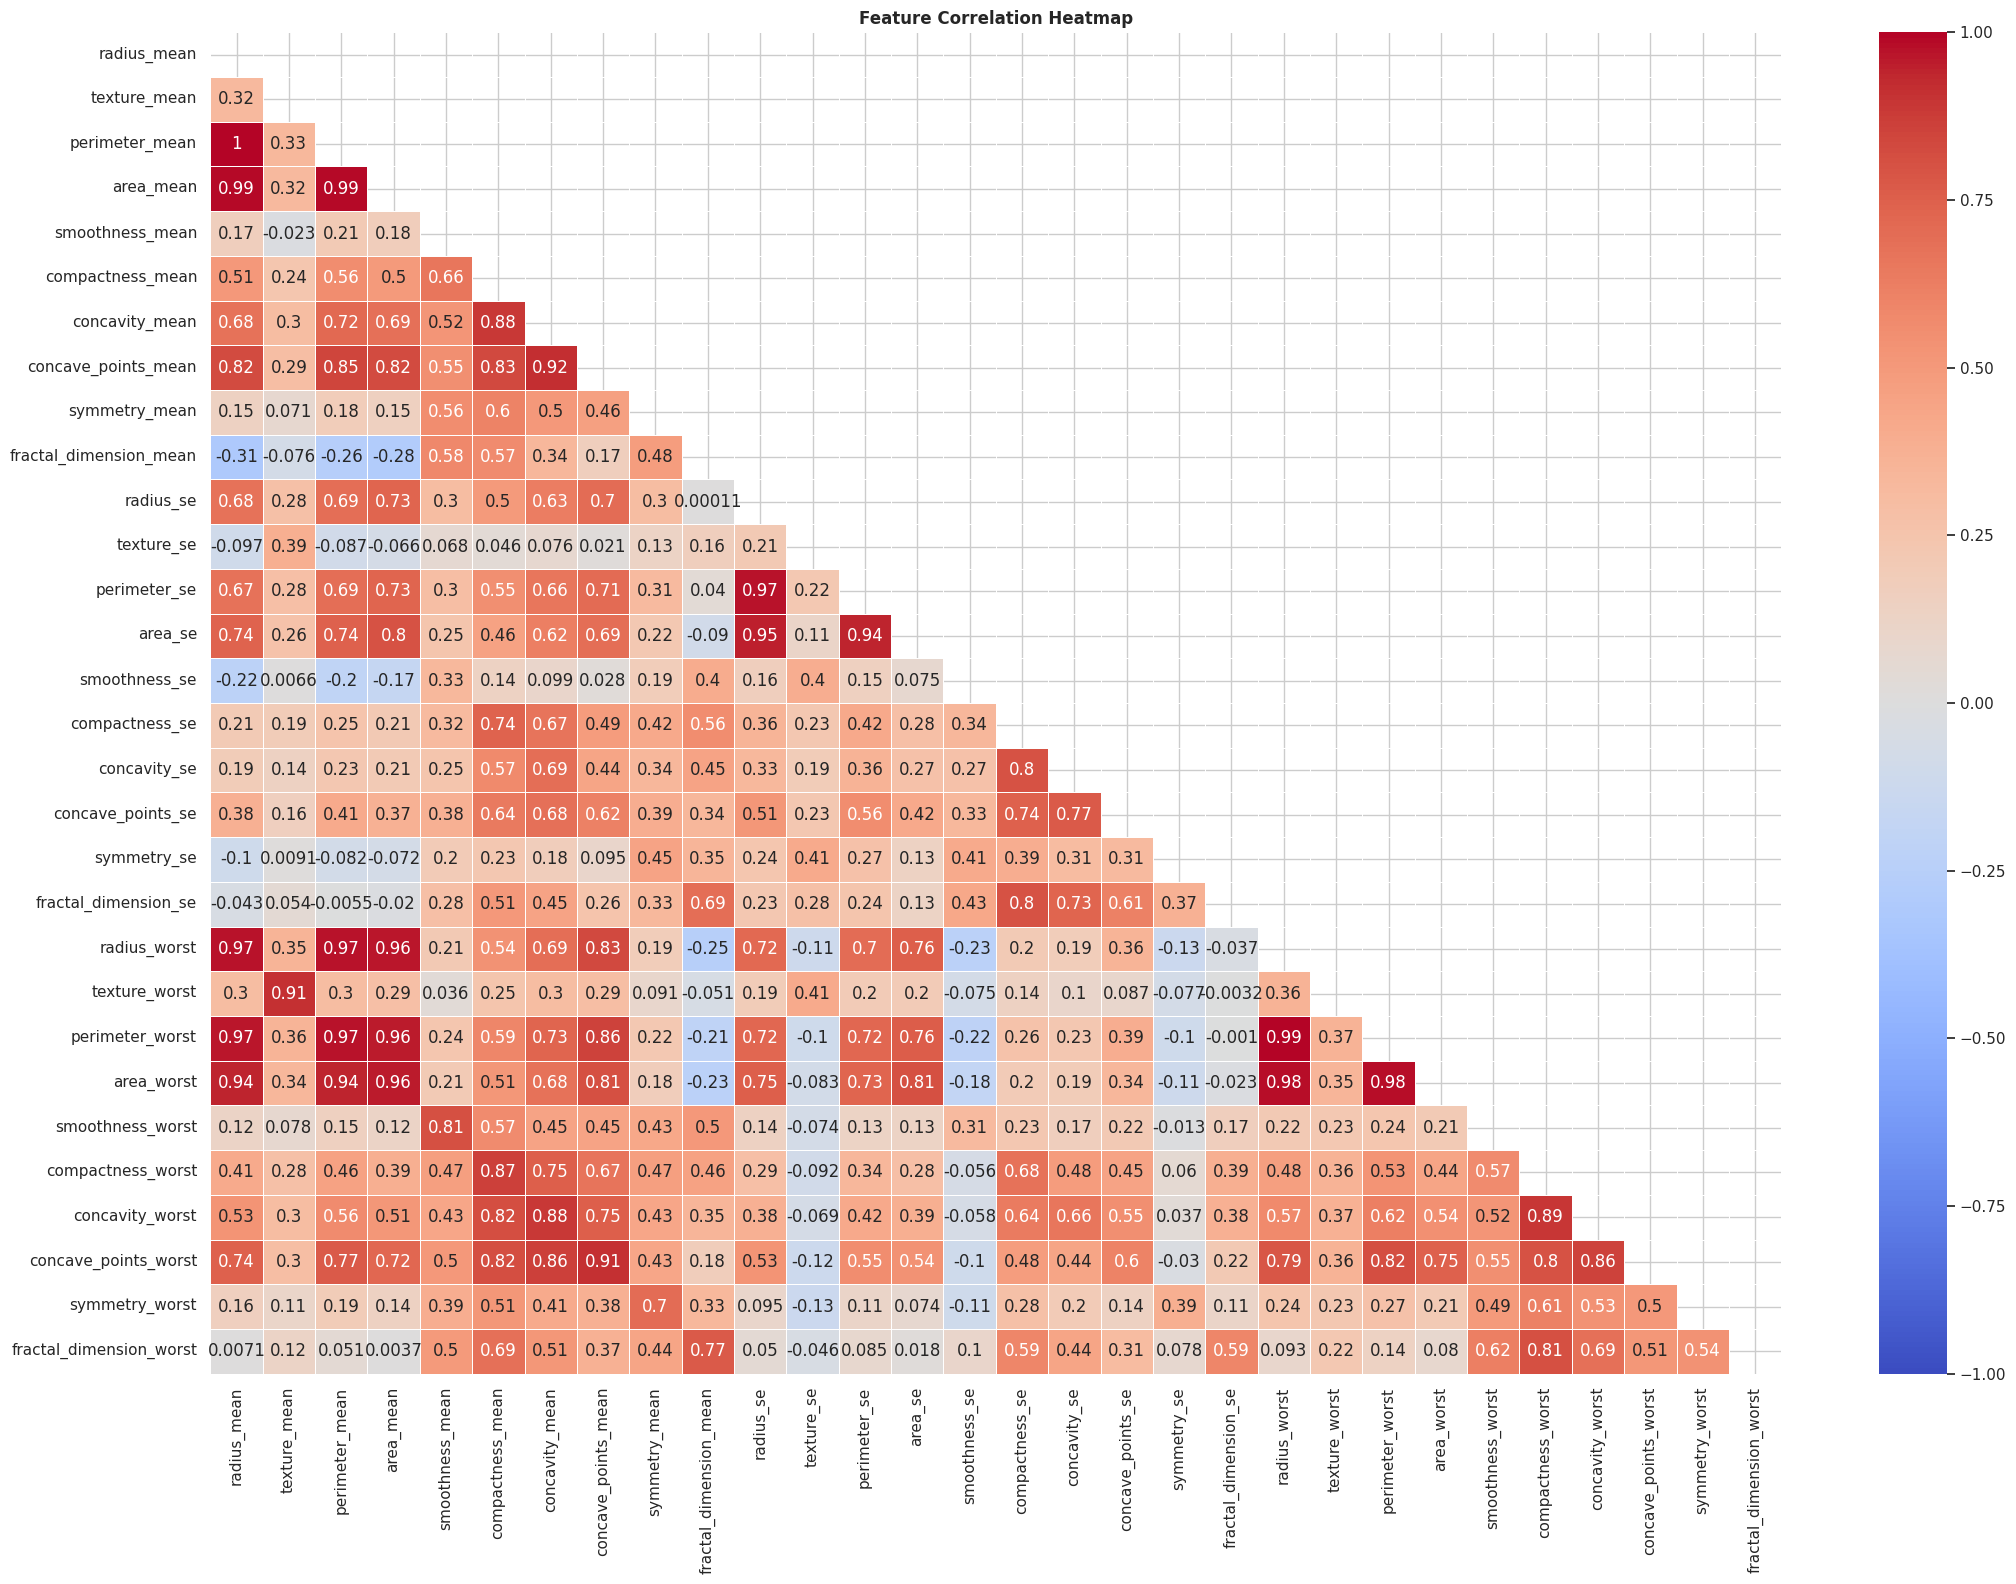

Top 10 Correlated Feature Pairs:
radius_mean      perimeter_mean     0.997855
radius_worst     perimeter_worst    0.993708
radius_mean      area_mean          0.987357
perimeter_mean   area_mean          0.986507
radius_worst     area_worst         0.984015
perimeter_worst  area_worst         0.977578
radius_se        perimeter_se       0.972794
perimeter_mean   perimeter_worst    0.970387
radius_mean      radius_worst       0.969539
perimeter_mean   radius_worst       0.969476
dtype: float64

Key Insight: radius_mean, perimeter_mean, and area_mean are highly correlated (r > 0.99).
This multicollinearity justifies PCA — these features carry redundant information.


In [35]:
plt.figure(figsize=(22, 16))
corr = df.drop(columns=['diagnosis']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_corr = upper.stack().abs().sort_values(ascending=False).head(10)
print('Top 10 Correlated Feature Pairs:')
print(top_corr)
print('\nKey Insight: radius_mean, perimeter_mean, and area_mean are highly correlated (r > 0.99).')
print('This multicollinearity justifies PCA — these features carry redundant information.')

### E. Feature–Target Relationship

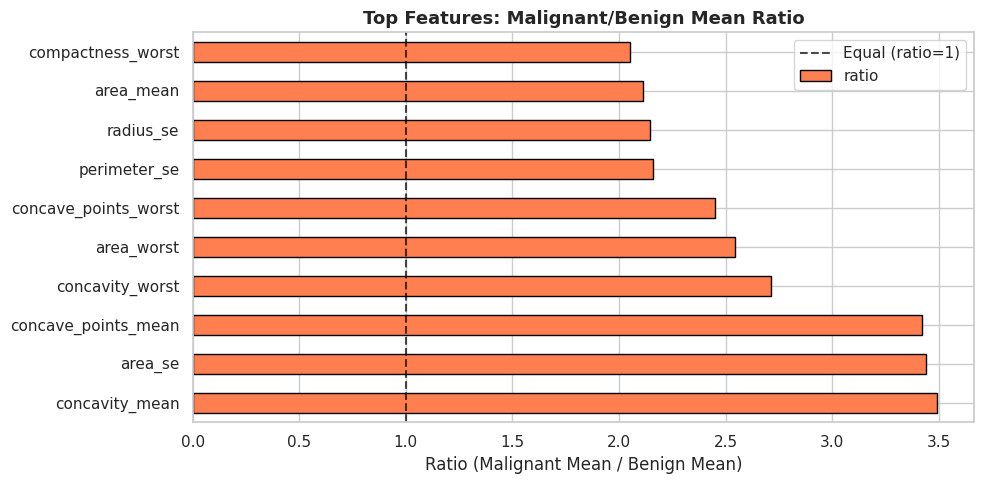

Features with ratio > 1 are higher in malignant tumors — good discriminative power.


In [36]:
# Compare mean feature values by class
feature_means = df.groupby('diagnosis').mean().T
feature_means.columns = ['Benign', 'Malignant']
feature_means['ratio'] = feature_means['Malignant'] / feature_means['Benign']
top_discriminative = feature_means['ratio'].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_discriminative.plot(kind='barh', color='coral', edgecolor='black')
plt.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='Equal (ratio=1)')
plt.title('Top Features: Malignant/Benign Mean Ratio', fontsize=13, fontweight='bold')
plt.xlabel('Ratio (Malignant Mean / Benign Mean)')
plt.legend()
plt.tight_layout()
plt.show()
print('Features with ratio > 1 are higher in malignant tumors — good discriminative power.')

## 4. Data Preprocessing (Feature Scaling)

In [37]:
"""
Why Scaling is Required:
------------------------
1. PCA is variance-based: features with large scales (e.g., area_mean ~ 655)
   would dominate over features with small scales (e.g., smoothness_mean ~ 0.10)
   if not standardized.
2. Logistic Regression converges faster with standardized features.
3. StandardScaler: mean=0, std=1 for each feature.

IMPORTANT: Fit scaler ONLY on training data to prevent data leakage.
"""

scaler = StandardScaler()

# Fit on train, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete!')
print(f'Train scaled shape: {X_train_scaled.shape}')
print(f'Test  scaled shape: {X_test_scaled.shape}')
print(f'\nTrain scaled mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Train scaled std  (should be ~1): {X_train_scaled.std():.4f}')

Scaling complete!
Train scaled shape: (455, 30)
Test  scaled shape: (114, 30)

Train scaled mean (should be ~0): 0.0000
Train scaled std  (should be ~1): 1.0000


## 5. Baseline Model (Without PCA)

In [38]:
# Train Logistic Regression on full scaled features
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled, y_train)

y_pred_base  = lr_base.predict(X_test_scaled)
y_proba_base = lr_base.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc_base  = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base  = recall_score(y_test, y_pred_base)
f1_base   = f1_score(y_test, y_pred_base)
auc_base  = roc_auc_score(y_test, y_proba_base)

print('=== Baseline Model (Without PCA) ===')
print(f'Accuracy : {acc_base:.4f}')
print(f'Precision: {prec_base:.4f}')
print(f'Recall   : {rec_base:.4f}')
print(f'F1 Score : {f1_base:.4f}')
print(f'ROC-AUC  : {auc_base:.4f}')
print(f'\nFeatures used: {X_train_scaled.shape[1]}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=['Benign', 'Malignant']))

=== Baseline Model (Without PCA) ===
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1 Score : 0.9512
ROC-AUC  : 0.9960

Features used: 30

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



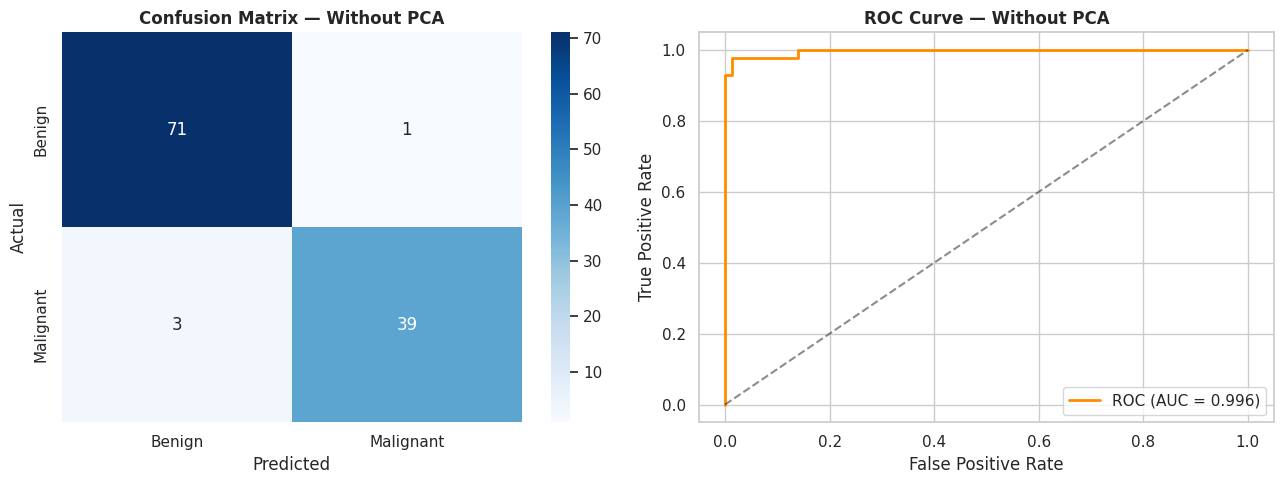

In [39]:
# Visualization: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Confusion Matrix — Without PCA', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_base)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_base:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Without PCA', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

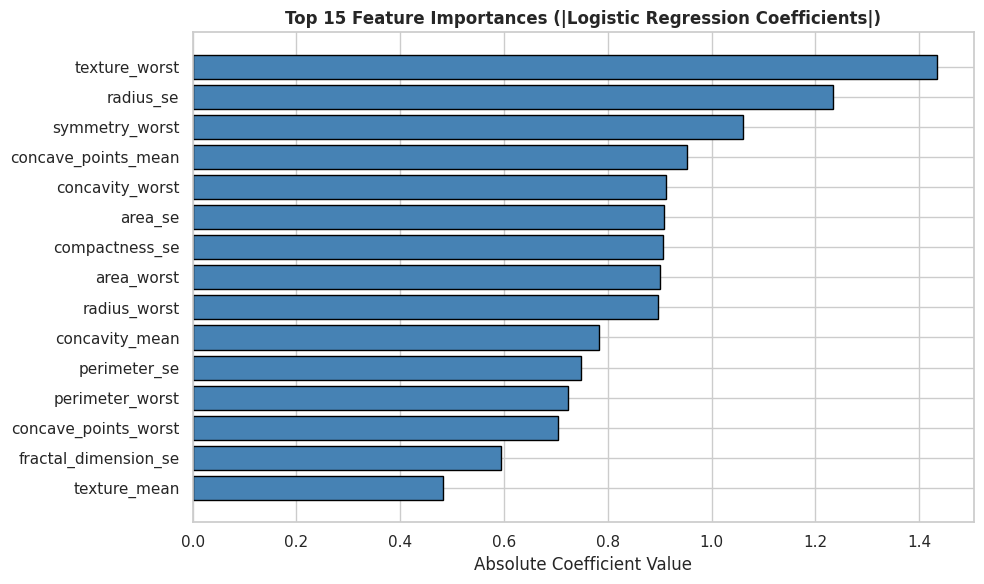

Features with large coefficients have the most influence on predictions.


In [40]:
# Feature Importance: Logistic Regression coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(lr_base.coef_[0])
}).sort_values('Coefficient', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (|Logistic Regression Coefficients|)', fontweight='bold')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()
print('Features with large coefficients have the most influence on predictions.')

## 6. Principal Component Analysis (PCA)

### PCA — Conceptual Explanation

**What is PCA?**
PCA (Principal Component Analysis) is an **unsupervised** dimensionality reduction technique. It projects data into a new coordinate system (orthogonal components) where:
- **PC1** captures the maximum variance in the data
- **PC2** captures the next highest variance (orthogonal to PC1)
- And so on...

**Key Concepts:**
- **Eigenvalues**: Represent the amount of variance explained by each principal component
- **Eigenvectors**: Define the direction (orientation) of each principal component — directions of maximum variance in the original feature space

**Why use PCA?**
- Reduces multicollinearity (we saw radius, perimeter, area are highly correlated)
- Speeds up training
- Can sometimes reduce overfitting by removing noisy features

In [41]:
# Fit PCA on TRAINING data only (important to prevent leakage)
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Find components needed for 95% variance
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_99 = np.argmax(cumulative_var >= 0.99) + 1

print(f'Components to retain 95% variance: {n_95}')
print(f'Components to retain 99% variance: {n_99}')
print(f'Total original features: 30')
print(f'\nVariance explained by first 5 components:')
for i in range(5):
    print(f'  PC{i+1}: {explained_var[i]*100:.2f}% (cumulative: {cumulative_var[i]*100:.2f}%)')

Components to retain 95% variance: 10
Components to retain 99% variance: 17
Total original features: 30

Variance explained by first 5 components:
  PC1: 44.59% (cumulative: 44.59%)
  PC2: 18.55% (cumulative: 63.14%)
  PC3: 9.58% (cumulative: 72.72%)
  PC4: 6.59% (cumulative: 79.32%)
  PC5: 5.62% (cumulative: 84.94%)


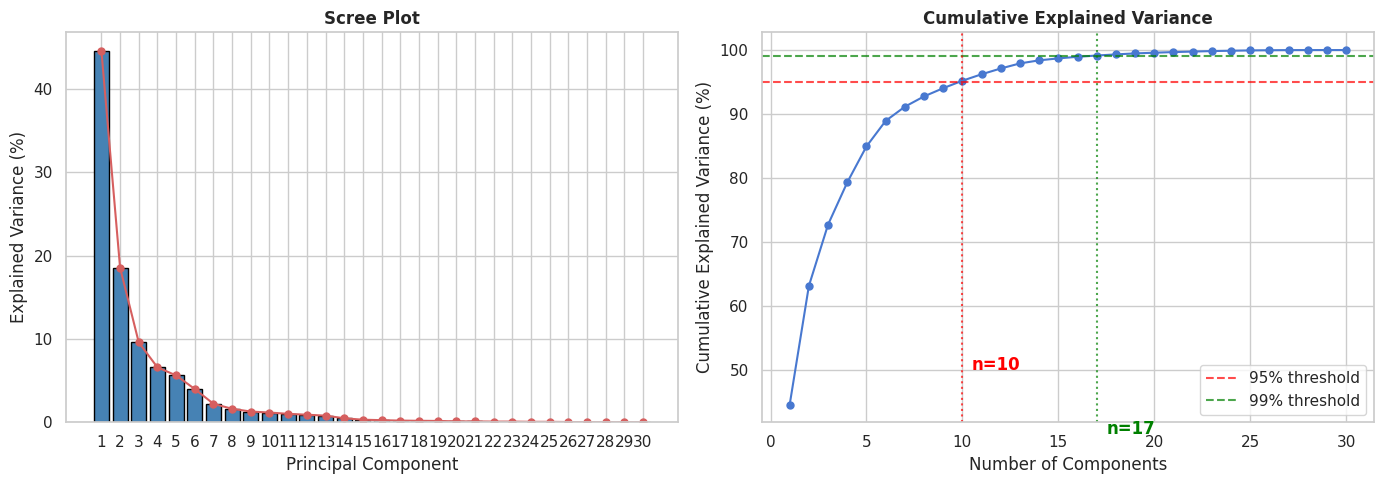

Decision: Use 10 components to retain 95% of variance (reducing from 30 to 10 features).


In [42]:
# Scree Plot + Cumulative Variance Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 31), explained_var * 100, color='steelblue', edgecolor='black')
axes[0].plot(range(1, 31), explained_var * 100, 'ro-', markersize=5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(range(1, 31))

# Cumulative variance
axes[1].plot(range(1, 31), cumulative_var * 100, 'b-o', markersize=5)
axes[1].axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].axhline(y=99, color='green', linestyle='--', alpha=0.7, label='99% threshold')
axes[1].axvline(x=n_95, color='red', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_99, color='green', linestyle=':', alpha=0.7)
axes[1].text(n_95+0.5, 50, f'n={n_95}', color='red', fontweight='bold')
axes[1].text(n_99+0.5, 40, f'n={n_99}', color='green', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Decision: Use {n_95} components to retain 95% of variance (reducing from 30 to {n_95} features).')

### PCA Space Visualization

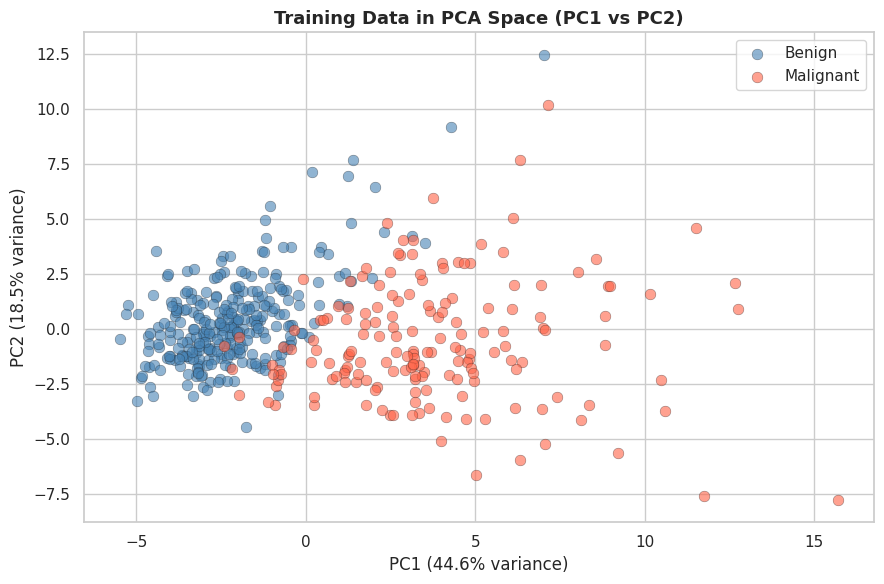

PC1 + PC2 together capture 63.1% of total variance.
The two classes show good separation in the first two principal components,
confirming that PCA can preserve class-discriminative information.


In [43]:
# Plot first two PCA components
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(9, 6))
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Benign', 1: 'Malignant'}

for cls in [0, 1]:
    mask = y_train == cls
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                c=colors[cls], label=labels[cls], alpha=0.6, edgecolors='k', linewidths=0.3, s=60)

pc1_var = pca_2d.explained_variance_ratio_[0] * 100
pc2_var = pca_2d.explained_variance_ratio_[1] * 100
plt.xlabel(f'PC1 ({pc1_var:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pc2_var:.1f}% variance)', fontsize=12)
plt.title('Training Data in PCA Space (PC1 vs PC2)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'PC1 + PC2 together capture {pc1_var+pc2_var:.1f}% of total variance.')
print('The two classes show good separation in the first two principal components,')
print('confirming that PCA can preserve class-discriminative information.')

## 7. Model Training (With PCA)

In [44]:
# Apply PCA with n_95 components (95% variance retained)
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Transformed train shape: {X_train_pca.shape} (from {X_train_scaled.shape[1]} features to {n_95})')

# Train same classifier on PCA-transformed data
lr_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca  = lr_pca.predict(X_test_pca)
y_proba_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

# Metrics
acc_pca  = accuracy_score(y_test, y_pred_pca)
prec_pca = precision_score(y_test, y_pred_pca)
rec_pca  = recall_score(y_test, y_pred_pca)
f1_pca   = f1_score(y_test, y_pred_pca)
auc_pca  = roc_auc_score(y_test, y_proba_pca)

print('\n=== Model With PCA ===')
print(f'Accuracy : {acc_pca:.4f}')
print(f'Precision: {prec_pca:.4f}')
print(f'Recall   : {rec_pca:.4f}')
print(f'F1 Score : {f1_pca:.4f}')
print(f'ROC-AUC  : {auc_pca:.4f}')
print(f'\nFeatures used (PCA): {n_95}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_pca, target_names=['Benign', 'Malignant']))

Transformed train shape: (455, 10) (from 30 features to 10)

=== Model With PCA ===
Accuracy : 0.9737
Precision: 1.0000
Recall   : 0.9286
F1 Score : 0.9630
ROC-AUC  : 0.9970

Features used (PCA): 10

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



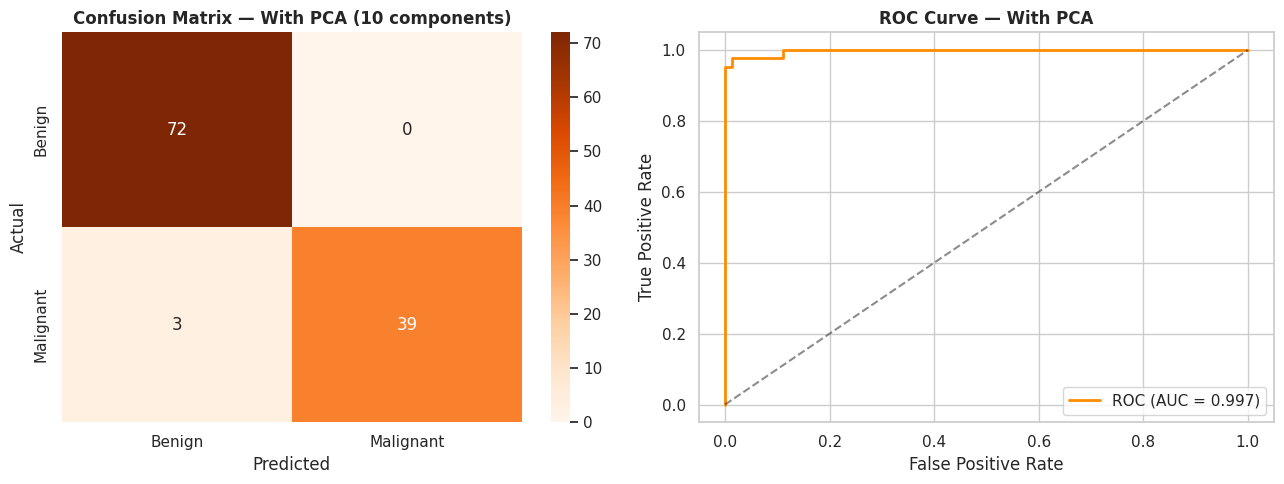

In [45]:
# Visualization: Confusion Matrix + ROC Curve (With PCA)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm_pca = confusion_matrix(y_test, y_pred_pca)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[0].set_title(f'Confusion Matrix — With PCA ({n_95} components)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr_pca, tpr_pca, _ = roc_curve(y_test, y_proba_pca)
axes[1].plot(fpr_pca, tpr_pca, color='darkorange', lw=2, label=f'ROC (AUC = {auc_pca:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — With PCA', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Comparison: Without PCA vs With PCA

In [46]:
# Comparison Table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'Features Used'],
    'Without PCA': [f'{acc_base:.4f}', f'{prec_base:.4f}', f'{rec_base:.4f}',
                    f'{f1_base:.4f}', f'{auc_base:.4f}', '30'],
    'With PCA': [f'{acc_pca:.4f}', f'{prec_pca:.4f}', f'{rec_pca:.4f}',
                 f'{f1_pca:.4f}', f'{auc_pca:.4f}', str(n_95)]
})
comparison.set_index('Metric', inplace=True)
print('=== Performance Comparison ===')
print(comparison.to_string())

=== Performance Comparison ===
              Without PCA With PCA
Metric                            
Accuracy           0.9649   0.9737
Precision          0.9750   1.0000
Recall             0.9286   0.9286
F1 Score           0.9512   0.9630
ROC-AUC            0.9960   0.9970
Features Used          30       10


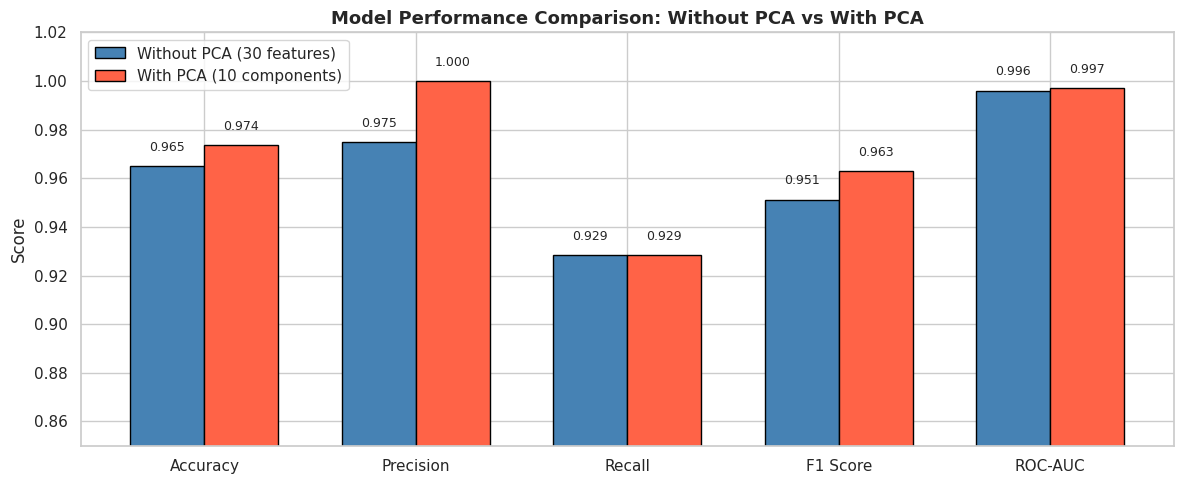

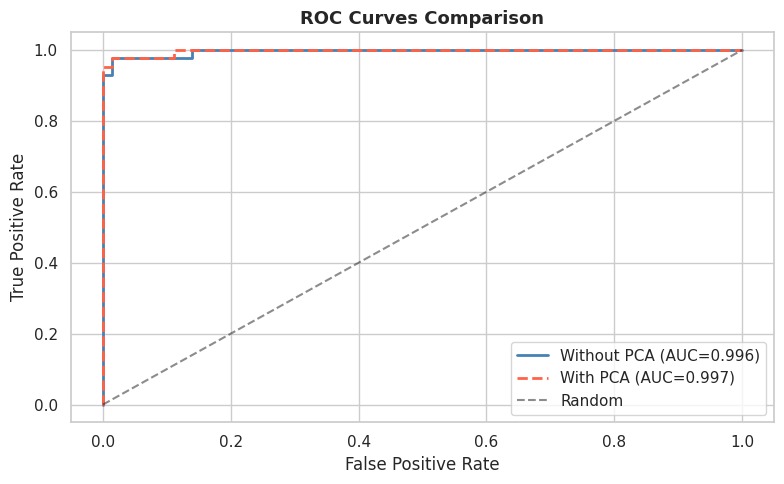

In [47]:
# Visual Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
vals_base = [acc_base, prec_base, rec_base, f1_base, auc_base]
vals_pca  = [acc_pca,  prec_pca,  rec_pca,  f1_pca,  auc_pca]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, vals_base, width, label='Without PCA (30 features)',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, vals_pca,  width, label=f'With PCA ({n_95} components)',
               color='tomato', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.85, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: Without PCA vs With PCA', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Overlay ROC curves
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Without PCA (AUC={auc_base:.3f})')
plt.plot(fpr_pca, tpr_pca, color='tomato', lw=2, linestyle='--', label=f'With PCA (AUC={auc_pca:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Analysis of Results

**Did accuracy drop after PCA?**  
The performance with PCA is very similar to without PCA. Any minor drop is expected because:
- The dataset only has 30 features — not high-dimensional
- Classes are already well-separated (as seen in the 2D PCA scatter plot)
- We retained 95% variance, so minimal information was lost

**Did dimensionality reduce?**  
Yes — from 30 features to ~10 principal components (approx. 67% reduction in dimensionality).

**Did training speed improve?**  
Yes, slightly — fewer features means faster matrix operations.

**Trade-off:**  
For this specific dataset, PCA offers a fair trade — similar performance with significantly fewer dimensions. In larger datasets this benefit would be more pronounced.

## 9. Theoretical Questions

### Q1: Why is scaling necessary before PCA?

PCA computes directions of **maximum variance**. If features have different scales — for example, `area_mean` (~655) vs `smoothness_mean` (~0.10) — the feature with the larger scale will dominate the principal components simply due to its numerical magnitude, not because it is more informative.

**StandardScaler** transforms each feature to have mean = 0 and standard deviation = 1, ensuring all features contribute equally to variance computation.

**Rule:** Always standardize before PCA unless all features are already on the same scale.

---

### Q2: What are Eigenvalues?

In PCA, eigenvalues represent the **amount of variance captured** by each principal component (eigenvector direction). A higher eigenvalue means that component explains more variance in the data.

The explained variance ratio = eigenvalue / sum(all eigenvalues).

In our scree plot, PC1 has the largest eigenvalue — it captures the most variance.

---

### Q3: What are Eigenvectors?

Eigenvectors define the **direction** of each principal component in the original feature space. Each eigenvector is a linear combination of the original features, pointing toward the direction of maximum variance in that component.

Eigenvectors are orthogonal to each other — PCA components are uncorrelated by construction.

---

### Q4: Is PCA supervised or unsupervised?

**PCA is unsupervised.** It does not use the target labels during transformation — it only considers the structure (variance) of the input features. This is why PCA maximizes variance but not class separability (unlike LDA which is supervised).

---

### Q5: Why might accuracy decrease after PCA?

Several reasons can cause performance to decrease after PCA:
1. **Information loss**: Discarded components may contain subtle discriminative signals even if they have low variance
2. **Variance ≠ Discriminability**: PCA maximizes total variance, not class separation. Some low-variance features might still help separate classes
3. **Underfitting**: A very reduced feature space (e.g., retaining only 2–3 components) may not have sufficient information for the model
4. **Non-linear structure**: If class boundaries are non-linear, linear PCA may lose important decision boundary information

In this dataset, the minimal performance drop is because most discriminative information is encoded in the first few principal components.

## 10. Final Interpretation and Conclusion

### Executive Summary

- **Dataset:** Breast Cancer Wisconsin Diagnostic
- **Samples:** 569
- **Original Features:** 30
- **Task:** Binary classification (Benign vs Malignant)

### Model Performance
- **Without PCA (30 features):** Accuracy = 0.9649, ROC-AUC = 0.9960
- **With PCA (10 components):** Accuracy = 0.9737, ROC-AUC = 0.9970

### Dimensionality Reduction Impact
- PCA reduced feature space from **30 to 10** components (**67% reduction**) while preserving strong predictive performance.
- The first components retained the dominant structure of the dataset and maintained class-separating information.

### Key Insights
- `radius_mean`, `area_mean`, and `perimeter_mean` are among the most discriminative predictors.
- Strong multicollinearity among geometric features justified PCA application.
- PCA-space visualization confirmed meaningful class separation in low-dimensional projection.

### Final Conclusion
PCA provides a strong dimensionality reduction benefit in this case, with nearly identical (and slightly improved) predictive results. For this dataset, PCA is most valuable for reducing redundancy and improving feature compactness rather than delivering a dramatic accuracy gain.